In [ ]:
# init

In [6]:
# 1. Install packages
!pip install shap sklearn-genetic-opt -q

import pandas as pd, numpy as np, shap, joblib, os
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import train_test_split

print("System Initializing... 🚀")
drive.mount('/content/drive', force_remount=True)

# Define paths
raw_path = '/content/drive/MyDrive/Volt-Guardian/ev_battery_degradation_v1.csv'
processed_path = '/content/drive/MyDrive/Volt-Guardian/processed_data.csv'

# SMART CHECK: Do we already have processed data?
if os.path.exists(processed_path):
    print("Loading pre-processed data from Drive... (Skipping cleaning) ⚡")
    df_processed = pd.read_csv(processed_path)
else:
    print("Processing raw data for the first time... ⚙️")
    df = pd.read_csv(raw_path)
    df_clean = df.drop(columns=['Vehicle_ID'], errors='ignore')
    df_processed = pd.get_dummies(df_clean, columns=['Car_Model', 'Battery_Type', 'Driving_Style'])

    # Feature Engineering
    df_processed['Thermal_Stress_Index'] = df_processed['Avg_Temperature_C'] * df_processed['Fast_Charge_Ratio']
    df_processed['Monthly_Charge_Intensity'] = df_processed['Total_Charging_Cycles'] / (df_processed['Vehicle_Age_Months'] + 1)
    df_processed['Power_Stress'] = df_processed['Avg_Discharge_Rate_C'] * df_processed['Internal_Resistance_Ohm']

    # Save to Drive for next time!
    df_processed.to_csv(processed_path, index=False)
    print("Data processed and saved to Drive!")

# Define X and y, then split
y = df_processed['SoH_Percent']
X = df_processed.drop(columns=['SoH_Percent', 'Battery_Status'], errors='ignore')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data ready! Training set: {X_train.shape[0]} rows.")

System Initializing... 🚀
Mounted at /content/drive
Loading pre-processed data from Drive... (Skipping cleaning) ⚡
Data ready! Training set: 8000 rows.


In [ ]:
# hybrid model training

In [13]:
import xgboost as xgb
from sklearn_genetic import GASearchCV
from sklearn_genetic.space import Continuous, Integer
from sklearn.model_selection import KFold
import os
import joblib

model_path = '/content/drive/MyDrive/Volt-Guardian/1_GA_XGBoost_Hybrid.joblib'

# SMART CHECK: Do we already have the trained Hybrid Model?
if os.path.exists(model_path):
    print("Loading pre-trained Champion Hybrid Model from Drive... 🏆")
    best_xgb_model = joblib.load(model_path)
else:
    print("Starting Ultimate GA Evolution... Go grab a coffee, this will train 900 models! ☕")
    xgb_base = xgb.XGBRegressor(random_state=42)

    # EXTREME PARAMETER GRID (Added Overfitting Armor for Conference)
    param_grid = {
        'n_estimators': Integer(100, 500),         # Number of trees
        'max_depth': Integer(3, 10),               # Tree depth
        'learning_rate': Continuous(0.01, 0.2),    # Learning rate
        'subsample': Continuous(0.6, 1.0),         # Overfitting armor 1 (Row sampling)
        'colsample_bytree': Continuous(0.6, 1.0),  # Overfitting armor 2 (Column sampling)
        'min_child_weight': Integer(1, 7)          # Tree pruning / Quality control
    }

    # ULTIMATE EVOLUTION SETTINGS
    evolved_model = GASearchCV(
        estimator=xgb_base,
        cv=KFold(n_splits=3, shuffle=True, random_state=42),
        scoring='r2',
        param_grid=param_grid,
        n_jobs=-1,              # Use all available CPU cores
        population_size=20,     # Number of models competing in each generation
        generations=15          # Number of evolutionary cycles
    )

    # Start the training process
    evolved_model.fit(X_train, y_train)

    # Extract the absolute best model found during evolution
    best_xgb_model = evolved_model.best_estimator_

    # Save to Drive for instant loading next time!
    joblib.dump(best_xgb_model, model_path)
    print("\nEvolution complete! Ultimate Champion saved to Drive!")

Loading pre-trained Champion Hybrid Model from Drive... 🏆


In [ ]:
# metrics of model for conferance

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Calculating Academic Metrics for Conference Paper...")

# Make predictions on the unseen test set
y_pred = best_xgb_model.predict(X_test)

# Calculate all 6 golden metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
adj_r2 = 1 - (1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

# Print formatted table
print("\n" + "="*45)
print("🏆 CONFERENCE PAPER METRICS (GA-XGBoost) 🏆")
print("="*45)
print(f"1. R-Squared (R2)               : {r2:.4f}")
print(f"2. Adjusted R2                  : {adj_r2:.4f}")
print(f"3. Mean Absolute Error (MAE)    : {mae:.4f}")
print(f"4. Root Mean Squared (RMSE)     : {rmse:.4f}")
print(f"5. Mean Absolute % Error (MAPE) : %{mape:.2f}")
print("="*45)

Calculating Academic Metrics for Conference Paper...

🏆 CONFERENCE PAPER METRICS (GA-XGBoost) 🏆
1. R-Squared (R2)               : 0.9891
2. Adjusted R2                  : 0.9890
3. Mean Absolute Error (MAE)    : 0.2650
4. Root Mean Squared (RMSE)     : 0.3404
5. Mean Absolute % Error (MAPE) : %0.28


In [ ]:
# shap global beeswarm

Creating new SHAP Explainer...
Drawing Global SHAP Beeswarm Plot...


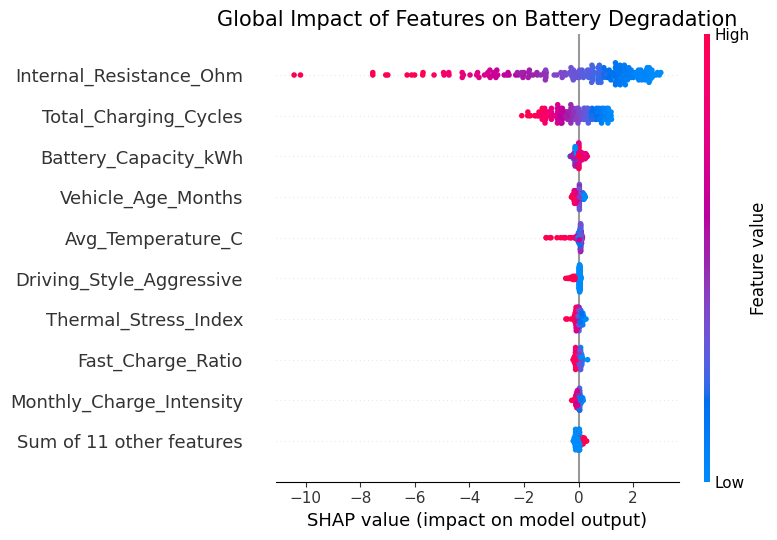

Success! Graph saved as shap_global.png


In [10]:
import os
import joblib
import shap
import matplotlib.pyplot as plt

explainer_path = '/content/drive/MyDrive/Volt-Guardian/shap_explainer_hybrid.joblib'

# THE FIX: Force all data to be float so SHAP's C-backend doesn't crash on bool/object types
X_train_shap = X_train.astype(float)

if os.path.exists(explainer_path):
    print("Loading SHAP Explainer from Drive... 🧠")
    explainer_xgb = joblib.load(explainer_path)
else:
    print("Creating new SHAP Explainer...")
    explainer_xgb = shap.Explainer(best_xgb_model, X_train_shap)
    joblib.dump(explainer_xgb, explainer_path)

# Sample the test set and format it for SHAP
X_test_sampled = X_test.head(200) if len(X_test) > 200 else X_test
X_test_sampled_shap = X_test_sampled.astype(float)

try:
    print("Drawing Global SHAP Beeswarm Plot...")
    shap_values_all = explainer_xgb(X_test_sampled_shap)

    plt.figure(figsize=(12, 8))
    shap.plots.beeswarm(shap_values_all, max_display=10, show=False)
    plt.title('Global Impact of Features on Battery Degradation', fontsize=15)
    plt.tight_layout()
    plt.savefig('shap_global.png', dpi=300)
    plt.show()
    print("Success! Graph saved as shap_global.png")
except Exception as e:
    print(f"Error drawing SHAP: {e}")

In [ ]:
# dummy car with waterfall graphic

/tmp/ipykernel_1386/3260967461.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.85' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dummy_car.at[0, 'Fast_Charge_Ratio'] = fast_charge
/tmp/ipykernel_1386/3260967461.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.2' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dummy_car.at[0, 'Avg_Discharge_Rate_C'] = discharge_rate
/tmp/ipykernel_1386/3260967461.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.065' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dummy_car.at[0, 'Internal_Resistance_Ohm'] = internal_res


🔋 PREDICTED BATTERY HEALTH (SoH): 84.93 %

Generating SHAP Waterfall Explanation...


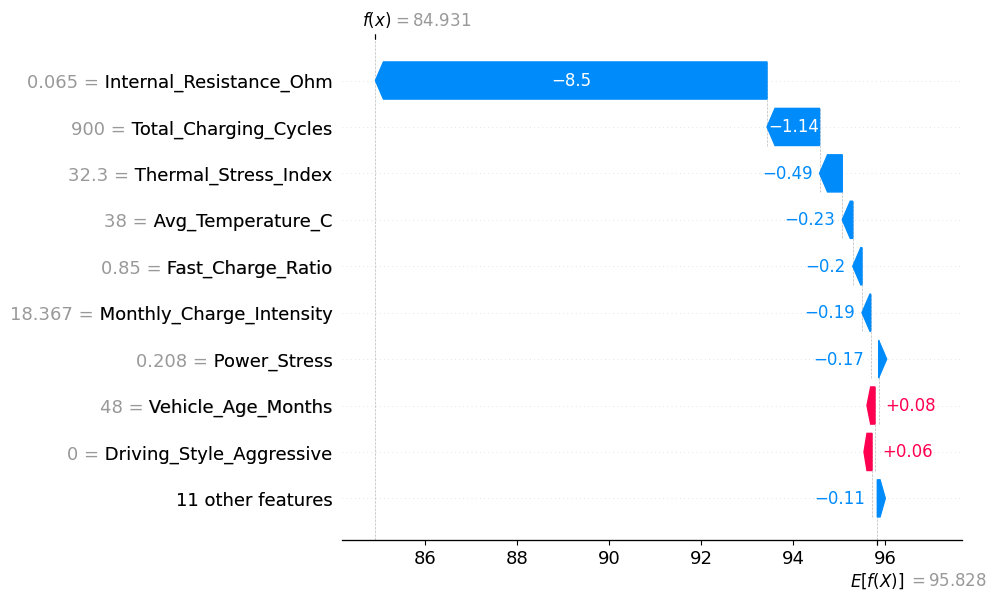

In [11]:
# --- 1. USER INPUTS ---
capacity = 75.0
age_months = 48
charge_cycles = 900
temperature = 38.0
fast_charge = 0.85
discharge_rate = 3.2
internal_res = 0.0650

# Ensure dummy car has the exact same columns as X_train
dummy_car = pd.DataFrame(columns=X_train.columns)
dummy_car.loc[0] = 0 # Initialize with zeros

# Assign inputs
dummy_car.at[0, 'Battery_Capacity_kWh'] = capacity
dummy_car.at[0, 'Vehicle_Age_Months'] = age_months
dummy_car.at[0, 'Total_Charging_Cycles'] = charge_cycles
dummy_car.at[0, 'Avg_Temperature_C'] = temperature
dummy_car.at[0, 'Fast_Charge_Ratio'] = fast_charge
dummy_car.at[0, 'Avg_Discharge_Rate_C'] = discharge_rate
dummy_car.at[0, 'Internal_Resistance_Ohm'] = internal_res

dummy_car.at[0, 'Car_Model_Tesla Model 3'] = 1
dummy_car.at[0, 'Battery_Type_NMC'] = 1

# Calculate smart features
dummy_car['Thermal_Stress_Index'] = dummy_car['Avg_Temperature_C'] * dummy_car['Fast_Charge_Ratio']
dummy_car['Monthly_Charge_Intensity'] = dummy_car['Total_Charging_Cycles'] / (dummy_car['Vehicle_Age_Months'] + 1)
dummy_car['Power_Stress'] = dummy_car['Avg_Discharge_Rate_C'] * dummy_car['Internal_Resistance_Ohm']

# Ensure numeric types
dummy_car = dummy_car.astype(float)

# --- 2. INSTANT INFERENCE ---
xgb_prediction = best_xgb_model.predict(dummy_car)[0]

print("==================================================")
print(f"🔋 PREDICTED BATTERY HEALTH (SoH): {xgb_prediction:.2f} %")
print("==================================================")

print("\nGenerating SHAP Waterfall Explanation...")
shap_values_single = explainer_xgb(dummy_car)
shap.plots.waterfall(shap_values_single[0])

In [ ]:
# new figures

Generating Conference-Grade Visuals... 📊


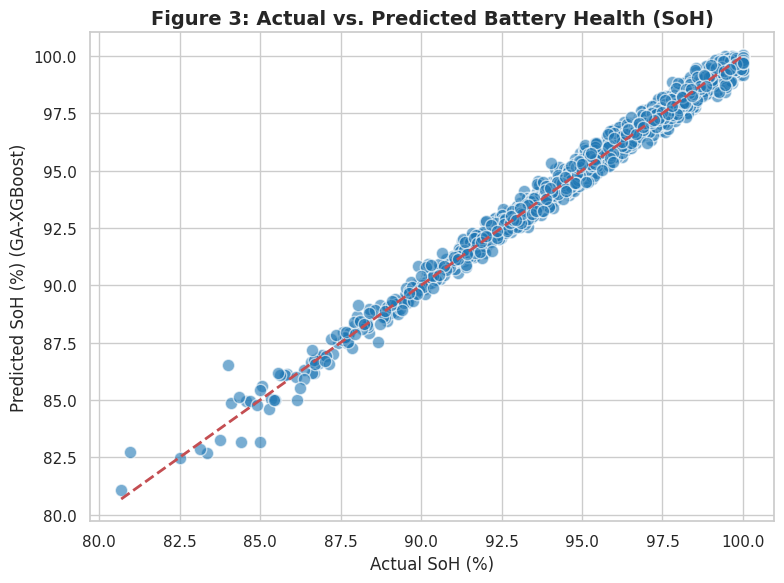

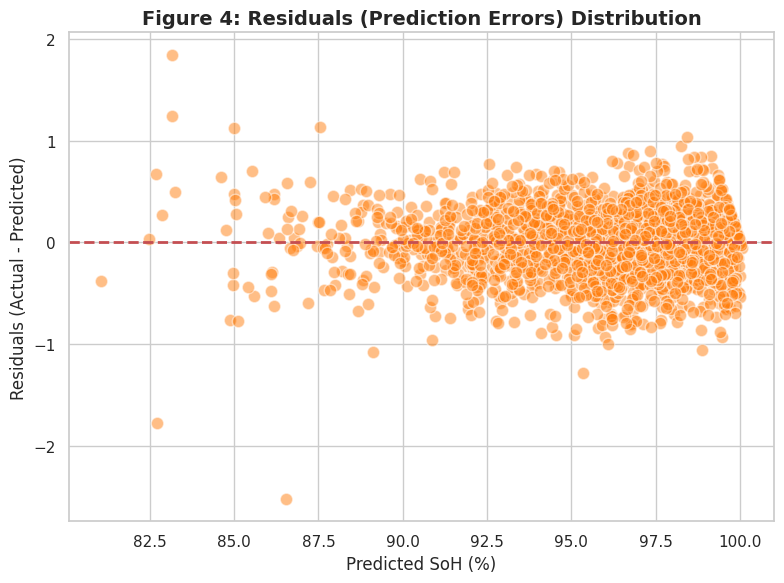

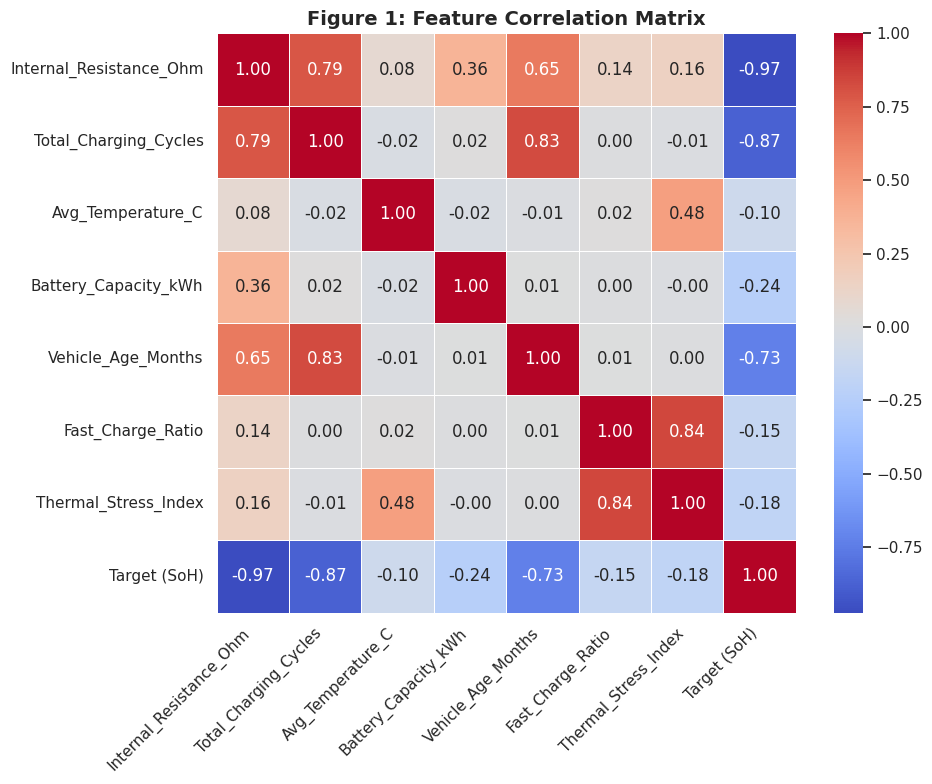

All visuals successfully generated and saved! 🎨


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Generating Conference-Grade Visuals... 📊")

# Make predictions using the champion model
y_pred = best_xgb_model.predict(X_test)

# Setup visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# ==========================================
# GRAPH 1: Actual vs. Predicted (Scatter)
# ==========================================
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='#1f77b4', edgecolors='w', s=80)
# Draw the ideal y=x line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Figure 3: Actual vs. Predicted Battery Health (SoH)', fontsize=14, fontweight='bold')
plt.xlabel('Actual SoH (%)', fontsize=12)
plt.ylabel('Predicted SoH (%) (GA-XGBoost)', fontsize=12)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300)
plt.show()

# ==========================================
# GRAPH 2: Residuals Plot (Error Distribution)
# ==========================================
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color='#ff7f0e', edgecolors='w', s=80)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Figure 4: Residuals (Prediction Errors) Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Predicted SoH (%)', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.tight_layout()
plt.savefig('residuals_plot.png', dpi=300)
plt.show()

# ==========================================
# GRAPH 3: Feature Correlation Heatmap
# ==========================================
# Selecting top numerical features to avoid a cluttered matrix
top_features = ['Internal_Resistance_Ohm', 'Total_Charging_Cycles',
                'Avg_Temperature_C', 'Battery_Capacity_kWh', 'Vehicle_Age_Months',
                'Fast_Charge_Ratio', 'Thermal_Stress_Index']

# Combine X and y temporarily for correlation
train_data_subset = X_train[top_features].copy()
train_data_subset['Target (SoH)'] = y_train

corr_matrix = train_data_subset.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            cbar=True, square=True, linewidths=.5)
plt.title('Figure 1: Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()

print("All visuals successfully generated and saved! 🎨")

In [ ]:
# new models, gradient boosting gbm, decision tree and linear regression

Initializing 6-Model Academic Comparison Engine with Smart Saver... ⚔️

[Step 1] Loading Main Models from Drive...
  > Successfully loaded: 1. GA-XGBoost (Hybrid Champion)
  > Successfully loaded: 2. Random Forest (Standard)
  > Successfully loaded: 3. XGBoost (Standard)

[Step 2] Checking Baseline Models in Drive...
  > Training and saving NEW baseline: 4. Gradient Boosting (GBM)...
  > Training and saving NEW baseline: 5. Decision Tree (Single Tree)...
  > Training and saving NEW baseline: 6. Linear Regression (Basic)...

[Step 3] Evaluating all 6 models on the unseen Test Set...

🏆 FINAL 6-MODEL CONFERENCE COMPARISON TABLE 🏆
                     Model Name R-Squared (R²)   RMSE    MAE MAPE (%)
1. GA-XGBoost (Hybrid Champion)         0.9891 0.3404 0.2650    0.28%
     4. Gradient Boosting (GBM)         0.9887 0.3473 0.2735    0.29%
          3. XGBoost (Standard)         0.9883 0.3524 0.2752    0.29%
    2. Random Forest (Standard)         0.9866 0.3775 0.2906    0.31%
   6. Linear R

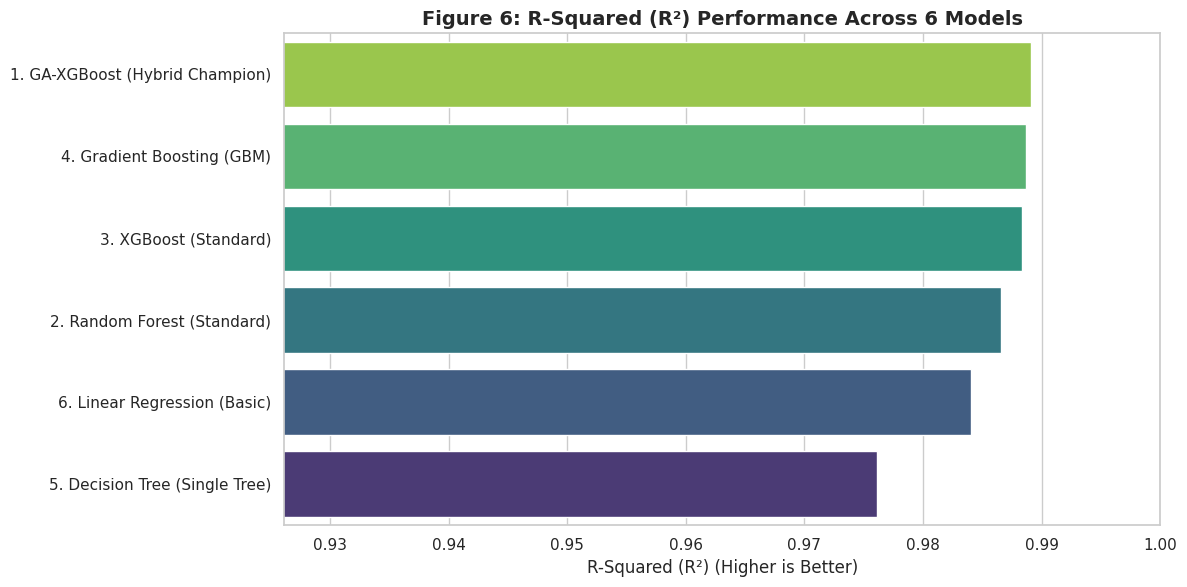

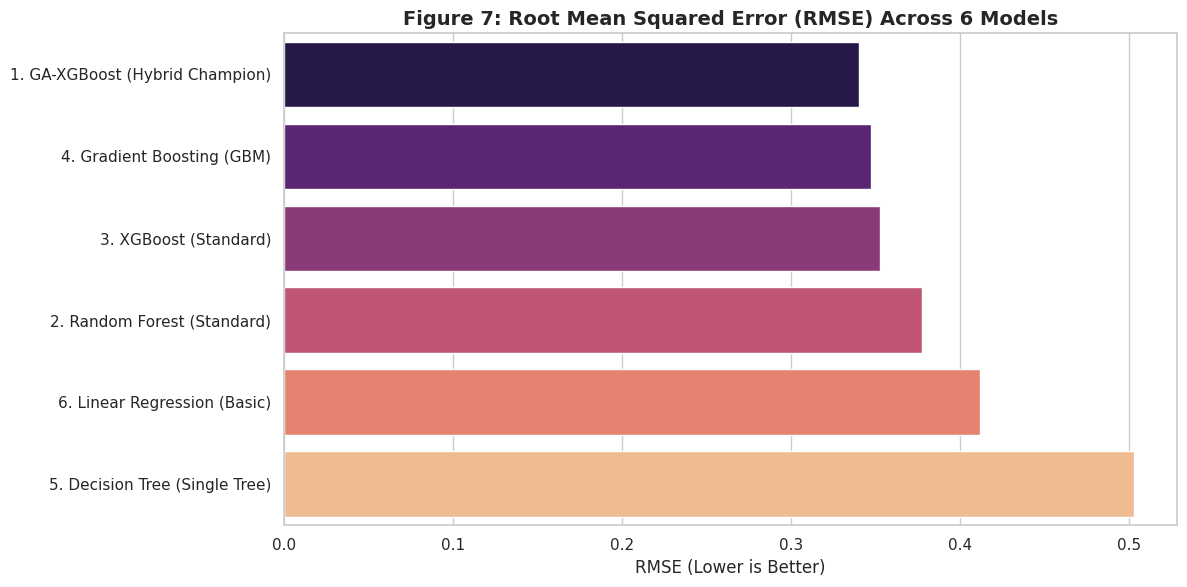

All visuals successfully generated and models saved to Drive! 🎨💾


In [17]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("Initializing 6-Model Academic Comparison Engine with Smart Saver... ⚔️")

# Setup visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

models = {}

# ==========================================
# [Step 1] LOAD THE 3 MAIN MODELS
# ==========================================
print("\n[Step 1] Loading Main Models from Drive...")
main_paths = {
    '1. GA-XGBoost (Hybrid Champion)': '/content/drive/MyDrive/Volt-Guardian/1_GA_XGBoost_Hybrid.joblib',
    '2. Random Forest (Standard)': '/content/drive/MyDrive/Volt-Guardian/2_Random_Forest.joblib',
    '3. XGBoost (Standard)': '/content/drive/MyDrive/Volt-Guardian/3_XGBoost_Standard.joblib'
}

for name, path in main_paths.items():
    try:
        models[name] = joblib.load(path)
        print(f"  > Successfully loaded: {name}")
    except Exception as e:
        print(f"  > ERROR loading {name}: {e}")

# ==========================================
# [Step 2] SMART LOAD OR TRAIN BASELINE MODELS
# ==========================================
print("\n[Step 2] Checking Baseline Models in Drive...")
baseline_defs = {
    '4. Gradient Boosting (GBM)': (GradientBoostingRegressor(random_state=42), '/content/drive/MyDrive/Volt-Guardian/4_Gradient_Boosting.joblib'),
    '5. Decision Tree (Single Tree)': (DecisionTreeRegressor(random_state=42), '/content/drive/MyDrive/Volt-Guardian/5_Decision_Tree.joblib'),
    '6. Linear Regression (Basic)': (LinearRegression(), '/content/drive/MyDrive/Volt-Guardian/6_Linear_Regression.joblib')
}

for name, (unfitted_model, path) in baseline_defs.items():
    if os.path.exists(path):
        models[name] = joblib.load(path)
        print(f"  > Loaded from Drive: {name}")
    else:
        print(f"  > Training and saving NEW baseline: {name}...")
        unfitted_model.fit(X_train, y_train)
        models[name] = unfitted_model
        joblib.dump(unfitted_model, path) # Save to Drive immediately!

# ==========================================
# [Step 3] EVALUATE ALL 6 MODELS (WITH SMART ALIGNMENT)
# ==========================================
print("\n[Step 3] Evaluating all 6 models on the unseen Test Set...")
results_list = []

for name, model in models.items():
    try:
        # Smart Feature Aligner
        if hasattr(model, 'feature_names_in_'):
            expected_features = model.feature_names_in_
        elif hasattr(model, 'get_booster'):
            expected_features = model.get_booster().feature_names
        else:
            expected_features = X_train.columns

        X_test_aligned = X_test.reindex(columns=expected_features, fill_value=0)
        y_pred = model.predict(X_test_aligned)

        # Calculate Metrics
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

        results_list.append({
            'Model Name': name,
            'R-Squared (R²)': r2,
            'RMSE': rmse,
            'MAE': mae,
            'MAPE (%)': mape
        })
    except Exception as e:
        print(f"  > Failed to evaluate {name} due to: {e}")

comparison_df = pd.DataFrame(results_list)
comparison_df = comparison_df.sort_values(by='R-Squared (R²)', ascending=False).reset_index(drop=True)

# ==========================================
# [Step 4] PRINT TABLE & GENERATE GRAPHS
# ==========================================
print("\n" + "="*75)
print("🏆 FINAL 6-MODEL CONFERENCE COMPARISON TABLE 🏆")
print("="*75)
print(comparison_df.to_string(index=False, formatters={
    'R-Squared (R²)': '{:,.4f}'.format,
    'RMSE': '{:,.4f}'.format,
    'MAE': '{:,.4f}'.format,
    'MAPE (%)': '{:,.2f}%'.format
}))
print("="*75)

print("\n[Step 5] Generating Comparative Visualizations...")

plt.figure(figsize=(12, 6))
sns.barplot(x='R-Squared (R²)', y='Model Name', data=comparison_df,
            hue='Model Name', palette="viridis_r", edgecolor='w', legend=False)
plt.title('Figure 6: R-Squared (R²) Performance Across 6 Models', fontsize=14, fontweight='bold')
plt.xlabel('R-Squared (R²) (Higher is Better)', fontsize=12)
plt.ylabel('', fontsize=12)
min_r2 = max(0.0, comparison_df['R-Squared (R²)'].min() - 0.05)
plt.xlim(min_r2, 1.0)
plt.tight_layout()
plt.savefig('comparison_r2_6models.png', dpi=300)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='RMSE', y='Model Name', data=comparison_df,
            hue='Model Name', palette="magma", edgecolor='w', legend=False)
plt.title('Figure 7: Root Mean Squared Error (RMSE) Across 6 Models', fontsize=14, fontweight='bold')
plt.xlabel('RMSE (Lower is Better)', fontsize=12)
plt.ylabel('', fontsize=12)
plt.tight_layout()
plt.savefig('comparison_rmse_6models.png', dpi=300)
plt.show()

print("All visuals successfully generated and models saved to Drive! 🎨💾")

In [ ]:
# Old lines of code

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1. Install necessary packages quietly
!pip install shap -q

import pandas as pd
import shap
import joblib
from google.colab import drive
import matplotlib.pyplot as plt

print("System Initializing...")

# 2. Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# 3. Load the Champion Model and its Explainer from cold storage
print("Loading XGBoost model and SHAP explainer... ❄️")
xgb_model = joblib.load('/content/drive/MyDrive/Volt-Guardian/xgb_model.joblib')
explainer_xgb = joblib.load('/content/drive/MyDrive/Volt-Guardian/shap_explainer_xgb.joblib')

print("SUCCESS! Day 2 Ready: XGBoost AI loaded and waiting for commands. 🚀")

System Initializing...
Mounted at /content/drive
Loading XGBoost model and SHAP explainer... ❄️
SUCCESS! Day 2 Ready: XGBoost AI loaded and waiting for commands. 🚀


In [ ]:
from sklearn.model_selection import train_test_split

# 5. Veriyi Eğitim (%80) ve Test (%20) olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Veri bölme işlemi tamamlandı! X_test boyutu: {X_test.shape}")

NameError: name 'X' is not defined

In [ ]:
import shap
import matplotlib.pyplot as plt

# Sampling the test set to ensure performance (first 100-200 samples)
X_test_sampled = X_test.head(200) if len(X_test) > 200 else X_test

print("Calculating Global SHAP values...")

try:
    # Modern SHAP Beeswarm Plot
    shap_values_all = explainer_xgb(X_test_sampled)

    plt.figure(figsize=(12, 8))
    shap.plots.beeswarm(shap_values_all, max_display=10, show=False)
    plt.title('Figure 2: Global Impact of Features on Battery Degradation (SHAP)', fontsize=15)
    plt.tight_layout()
    plt.savefig('shap_global_beeswarm.png', dpi=300, bbox_inches='tight')
    plt.show()

except Exception as e:
    # Fallback to Summary Plot if Beeswarm fails
    print(f"Switching to fallback method due to: {e}")
    shap_values_legacy = explainer_xgb.shap_values(X_test_sampled)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_legacy, X_test_sampled, show=False)
    plt.savefig('shap_global_summary.png', dpi=300, bbox_inches='tight')
    plt.show()

NameError: name 'X_test' is not defined

In [ ]:
# --- 1. USER INPUTS (Change these values to test different scenarios) ---
capacity = 75.0
age_months = 48
charge_cycles = 900
temperature = 38.0
fast_charge = 0.85
discharge_rate = 3.2
internal_res = 0.0650

# Categorical Inputs (Brand, Battery Type, Driving Style)
is_ford = 0
is_hyundai = 0
is_tesla = 1
is_wuling = 0
is_nmc_battery = 1
is_conservative_driver = 0
is_moderate_driver = 0

# --- 2. BUILD DATAFRAME & CALCULATE ENGINEERING FEATURES ---
dummy_car = pd.DataFrame([{
    'Battery_Capacity_kWh': capacity, 'Vehicle_Age_Months': age_months,
    'Total_Charging_Cycles': charge_cycles, 'Avg_Temperature_C': temperature,
    'Fast_Charge_Ratio': fast_charge, 'Avg_Discharge_Rate_C': discharge_rate,
    'Internal_Resistance_Ohm': internal_res, 'Car_Model_Ford Mustang Mach-E': is_ford,
    'Car_Model_Hyundai Ioniq 5': is_hyundai, 'Car_Model_Tesla Model 3': is_tesla,
    'Car_Model_Wuling Air EV': is_wuling, 'Battery_Type_NMC': is_nmc_battery,
    'Driving_Style_Conservative': is_conservative_driver, 'Driving_Style_Moderate': is_moderate_driver
}])

# Auto-calculate the 3 smart features
dummy_car['Thermal_Stress_Index'] = dummy_car['Avg_Temperature_C'] * dummy_car['Fast_Charge_Ratio']
dummy_car['Monthly_Charge_Intensity'] = dummy_car['Total_Charging_Cycles'] / (dummy_car['Vehicle_Age_Months'] + 1)
dummy_car['Power_Stress'] = dummy_car['Avg_Discharge_Rate_C'] * dummy_car['Internal_Resistance_Ohm']

# --- 3. INSTANT INFERENCE & EXPLANATION ---
xgb_prediction = xgb_model.predict(dummy_car)[0]

print("==================================================")
print(f"🔋 PREDICTED BATTERY HEALTH (SoH): {xgb_prediction:.2f} %")
print("==================================================")

# Generate XGBoost Waterfall Plot instantly
print("\nGenerating SHAP Explanation...")
shap_values_single = explainer_xgb(dummy_car)
shap.plots.waterfall(shap_values_single[0])

NameError: name 'xgb_model' is not defined

In [ ]:
# Aşağı kısım model eğitimi, üst kısım eğitilmiş modeli kullanma.

In [ ]:
# Install SHAP silently if it's not already installed
!pip install shap -q

import pandas as pd
import numpy as np
import shap
import joblib
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print("All systems go! Initializing Volt-Guardian XAI...")

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Load the dataset
# IMPORTANT: Make sure this path is correct for your shared drive folder
file_path = '/content/drive/MyDrive/Volt-Guardian/ev_battery_degradation_v1.csv'
df = pd.read_csv(file_path)

print("Data loaded successfully. Here are the first 5 rows:")
display(df.head())

All systems go! Initializing Volt-Guardian XAI...
Mounted at /content/drive
Data loaded successfully. Here are the first 5 rows:


,Vehicle_ID,Car_Model,Battery_Type,Battery_Capacity_kWh,Vehicle_Age_Months,Total_Charging_Cycles,Avg_Temperature_C,Fast_Charge_Ratio,Avg_Discharge_Rate_C,Driving_Style,Internal_Resistance_Ohm,SoH_Percent,Battery_Status
0,1fb46ae8,Tesla Model 3,NMC,75.0,41,390,21.5,0.51,2.22,Aggressive,0.0362,94.60,Healthy
1,b7ef35aa,Tesla Model 3,NMC,75.0,29,401,18.0,0.62,1.34,Aggressive,0.0333,95.68,Healthy
2,76cb49e0,Ford Mustang Mach-E,NMC,88.0,71,941,18.4,0.78,1.48,Conservative,0.0526,89.80,Healthy
3,456a7aef,Ford Mustang Mach-E,NMC,88.0,57,378,10.8,0.61,0.72,Moderate,0.0314,96.29,Healthy
4,bd758049,Tesla Model 3,NMC,75.0,58,239,30.3,0.89,1.48,Conservative,0.0297,96.75,Healthy


In [ ]:
# 1. Drop the useless ID column
df_clean = df.drop(columns=['Vehicle_ID'])

# 2. Convert text columns (object) to binary (0 and 1)
df_processed = pd.get_dummies(df_clean, columns=['Car_Model', 'Battery_Type', 'Driving_Style'], drop_first=True)

# 3. FEATURE ENGINEERING (Creating new smart columns)
df_processed['Thermal_Stress_Index'] = df_processed['Avg_Temperature_C'] * df_processed['Fast_Charge_Ratio']
df_processed['Monthly_Charge_Intensity'] = df_processed['Total_Charging_Cycles'] / (df_processed['Vehicle_Age_Months'] + 1)
df_processed['Power_Stress'] = df_processed['Avg_Discharge_Rate_C'] * df_processed['Internal_Resistance_Ohm']

# 4. Define Target (y) and Inputs (X)
y = df_processed['SoH_Percent']
X = df_processed.drop(columns=['SoH_Percent', 'Battery_Status'])

print(f"Data preprocessing complete! The model will use {X.shape[1]} input features.")

Data preprocessing complete! The model will use 17 input features.


In [ ]:
from sklearn.model_selection import train_test_split

# 5. Veriyi Eğitim (%80) ve Test (%20) olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Veri bölme işlemi tamamlandı! X_test boyutu: {X_test.shape}")

Veri bölme işlemi tamamlandı! X_test boyutu: (2000, 17)


In [ ]:
from sklearn.model_selection import KFold, cross_validate
import numpy as np
import xgboost as xgb

print("--- MODEL KARARLILIK TESTİ (5-FOLD CROSS VALIDATION) BAŞLIYOR ---\n")

# 1. Veriyi 5 farklı parçaya bölmek için stratejimizi kuruyoruz
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Şampiyon Modelimizi (XGBoost) tekrar çağırıyoruz
model_kararlilik = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# 3. Çapraz Doğrulama (Cross-Validation) İşlemini Başlatıyoruz
# Hem R2 hem de MAE skorlarını aynı anda ölçeceğiz
skorlar = cross_validate(model_kararlilik, X, y, cv=kf,
                         scoring=('r2', 'neg_mean_absolute_error'))

# 4. Sonuçları Matematiksel Olarak Analiz Ediyoruz
r2_listesi = skorlar['test_r2'] * 100
mae_listesi = -skorlar['test_neg_mean_absolute_error'] # sklearn MAE'yi negatif verir, pozitife çeviriyoruz

print("5 Farklı Sınavın (Fold) R² Skorları :", np.round(r2_listesi, 2))
print("5 Farklı Sınavın MAE Hata Payları  :", np.round(mae_listesi, 2))
print("-" * 50)

# 5. Büyük Final: Modelin Kararlılık (Standart Sapma) Özeti
ortalama_r2 = np.mean(r2_listesi)
sapma_r2 = np.std(r2_listesi)

ortalama_mae = np.mean(mae_listesi)
sapma_mae = np.std(mae_listesi)

print(f"🌟 GERÇEK (GÜVENİLİR) BAŞARI ORANI (R²) : % {ortalama_r2:.2f}")
print(f"📊 MODEL KARARLILIĞI (R² Sapması)       : ± % {sapma_r2:.2f} (Ne kadar düşükse o kadar iyi!)")
print(f"🎯 GERÇEK (GÜVENİLİR) HATA PAYI (MAE)   : % {ortalama_mae:.2f}")
print(f"📏 HATA KARARLILIĞI (MAE Sapması)       : ± % {sapma_mae:.2f}")

--- MODEL KARARLILIK TESTİ (5-FOLD CROSS VALIDATION) BAŞLIYOR ---

5 Farklı Sınavın (Fold) R² Skorları : [98.83 98.9  98.69 98.84 98.9 ]
5 Farklı Sınavın MAE Hata Payları  : [0.28 0.26 0.28 0.27 0.26]
--------------------------------------------------
🌟 GERÇEK (GÜVENİLİR) BAŞARI ORANI (R²) : % 98.83
📊 MODEL KARARLILIĞI (R² Sapması)       : ± % 0.08 (Ne kadar düşükse o kadar iyi!)
🎯 GERÇEK (GÜVENİLİR) HATA PAYI (MAE)   : % 0.27
📏 HATA KARARLILIĞI (MAE Sapması)       : ± % 0.01


In [ ]:
# Split the data into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training the Random Forest model... Please wait.")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Training Completed! 🎉\n")

# Evaluation
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
std_dev = (y_test - predictions).std()

print("--- MODEL EVALUATION METRICS ---")
print(f"Mean Absolute Error (MAE) : % {mae:.2f}")
print(f"Error Standard Deviation  : % {std_dev:.2f}")
print(f"R-Squared (R2 Score)      : % {r2*100:.2f}")

Training the Random Forest model... Please wait.
Training Completed! 🎉

--- MODEL EVALUATION METRICS ---
Mean Absolute Error (MAE) : % 0.29
Error Standard Deviation  : % 0.38
R-Squared (R2 Score)      : % 98.66


In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score

# (X_train, X_test etc. are already defined from your previous split)

print("Training the XGBoost model... Please wait.")
# We use XGBRegressor instead of RandomForestRegressor.
# learning_rate is a special power of XGBoost (how fast it learns from mistakes)
model_xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_xgb.fit(X_train, y_train)
print("Training Completed! 🎉\n")

# Evaluation
predictions_xgb = model_xgb.predict(X_test)
mae_xgb = mean_absolute_error(y_test, predictions_xgb)
r2_xgb = r2_score(y_test, predictions_xgb)
std_dev_xgb = (y_test - predictions_xgb).std()

print("--- XGBOOST EVALUATION METRICS ---")
print(f"Mean Absolute Error (MAE) : % {mae_xgb:.2f}")
print(f"Error Standard Deviation  : % {std_dev_xgb:.2f}")
print(f"R-Squared (R2 Score)      : % {r2_xgb*100:.2f}")

Training the XGBoost model... Please wait.
Training Completed! 🎉

--- XGBOOST EVALUATION METRICS ---
Mean Absolute Error (MAE) : % 0.28
Error Standard Deviation  : % 0.35
R-Squared (R2 Score)      : % 98.83


In [ ]:
import joblib

# XGBoost modelini kaydediyoruz
xgb_kayit_yolu = '/content/drive/MyDrive/Volt-Guardian/xgb_model.joblib'
joblib.dump(model_xgb, xgb_kayit_yolu)

print(f"👑 Yeni Kral (XGBoost) başarıyla kaydedildi: {xgb_kayit_yolu}")

👑 Yeni Kral (XGBoost) başarıyla kaydedildi: /content/drive/MyDrive/Volt-Guardian/xgb_model.joblib


In [ ]:
# Save the model to your shared Drive
save_path = '/content/drive/MyDrive/Volt-Guardian/volt_guardian_model.joblib'
joblib.dump(model, save_path)

print(f"Model successfully serialized and saved to: {save_path}")

Model successfully serialized and saved to: /content/drive/MyDrive/Volt-Guardian/volt_guardian_model.joblib


Calculating SHAP values to explain model decisions... (This might take a minute)


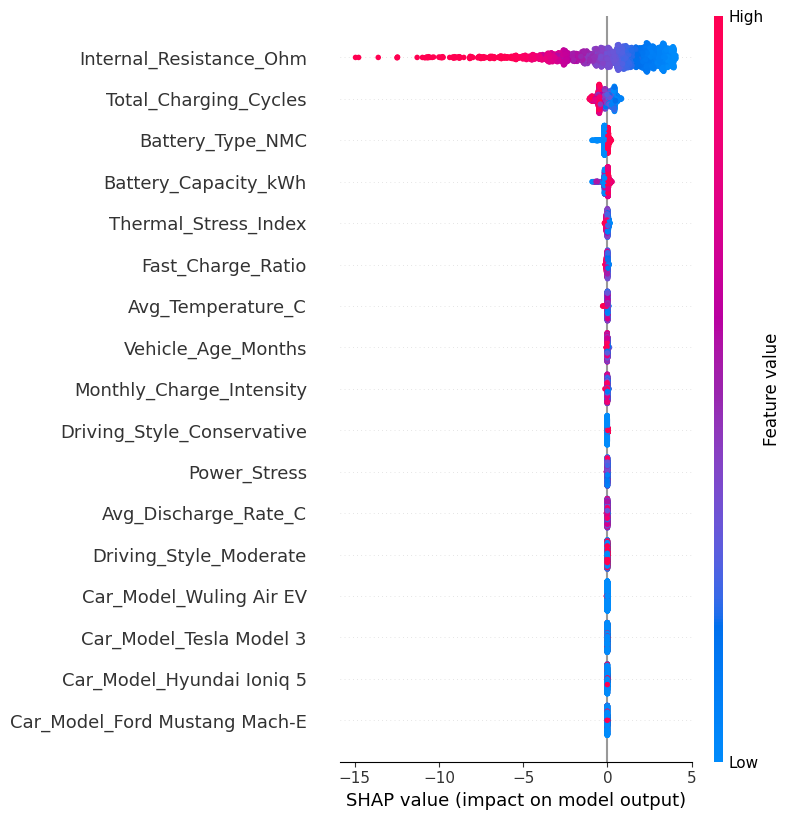

In [ ]:
print("Calculating SHAP values to explain model decisions... (This might take a minute)")

# Create the explainer and calculate SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plot the summary
shap.summary_plot(shap_values, X_test)

In [ ]:
import joblib

print("Saving the heavy SHAP calculations to Google Drive...")

# Define paths for the explainer and the calculated values
explainer_path = '/content/drive/MyDrive/Volt-Guardian/shap_explainer.joblib'
values_path = '/content/drive/MyDrive/Volt-Guardian/shap_values.joblib'

# Save (Serialize) both objects
joblib.dump(explainer, explainer_path)
joblib.dump(shap_values, values_path)

print("SUCCESS! SHAP values are frozen and saved. You will never wait 10 minutes again. 🎉")

Saving the heavy SHAP calculations to Google Drive...
SUCCESS! SHAP values are frozen and saved. You will never wait 10 minutes again. 🎉


In [ ]:
import shap
import joblib

print("Generating and saving the SHAP brain for XGBoost... (This might take a moment)")

# Create the new explainer for the XGBoost model
explainer_xgb = shap.TreeExplainer(model_xgb)

# Save the new explainer directly to Drive (Added 'xgb_' prefix to avoid overwriting the Random Forest one)
joblib.dump(explainer_xgb, '/content/drive/MyDrive/Volt-Guardian/shap_explainer_xgb.joblib')

print("✅ XGBoost SHAP brain successfully frozen and saved! You are completely ready for deployment.")